In [ ]:
# ==============================================================================
# Clase 08/08. SESIÓN 2 DEL MÓDULO 7: ALGORITMOS DE CLUSTERIZACIÓN
# Este código demuestra la implementación de los principales algoritmos de
# clusterización mencionados en la guía de estudio.
# El objetivo de la clusterización es agrupar datos sin etiquetas previas en
# grupos homogéneos.
# ==============================================================================

# 1. Importar las librerías necesarias
# numpy: Para la manipulación de arrays y la creación de datos.
# matplotlib.pyplot: Para la visualización de los resultados.
# sklearn.datasets.make_blobs: Para generar datos sintéticos de forma fácil.
# sklearn.cluster: Contiene los algoritmos de K-Means, DBSCAN y Clustering Jerárquico.
# sklearn.mixture: Contiene el algoritmo de Mezcla Gaussiana (GMM).
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

print("--- DEMOSTRACIÓN DE ALGORITMOS DE CLUSTERIZACIÓN ---")


--- DEMOSTRACIÓN DE ALGORITMOS DE CLUSTERIZACIÓN ---


make_blobs(...): Esta es una función de la librería scikit-learn que se utiliza para crear conjuntos de datos sintéticos ideales para probar algoritmos de clusterización. Genera puntos de datos agrupados en forma de "manchas" o "gotas".

n_samples=300: Con este parámetro, le estamos diciendo a la función que genere un total de 300 puntos de datos.

centers=4: Esto es muy importante. Le indicamos que queremos que los datos se distribuyan alrededor de 4 centros distintos. Esto significa que los datos se generarán de forma natural en 4 grupos diferentes, lo que nos permite probar si los algoritmos de clusterización son capaces de encontrar esos 4 grupos.

cluster_std=0.60: Este parámetro controla la desviación estándar (la "dispersión") de los puntos dentro de cada clúster. Un valor de 0.60 indica que los puntos estarán bastante juntos, formando clústeres bien definidos.

random_state=42: Al igual que en otros ejemplos, esto asegura que los datos generados sean exactamente los mismos cada vez que se ejecute el código, garantizando la reproducibilidad de la demostración.

X, y_true: La función devuelve dos variables: X (el conjunto de datos de los 300 puntos, sin etiquetas) e y_true (las etiquetas verdaderas de cada punto, que el algoritmo de clusterización no verá, pero que usamos para verificar nuestros resultados).

kmeans = KMeans(n_clusters=4, ...): Aquí se crea y configura el modelo de K-Means. Le estamos diciendo explícitamente que busque 4 clústeres (n_clusters=4), lo cual sabemos que es la respuesta correcta basándonos en cómo generamos los datos.

kmeans.fit(X): Este comando entrena el modelo. El algoritmo K-Means toma los datos en X (los 300 puntos) y los agrupa en 4 clústeres basándose en la distancia entre los puntos.

y_kmeans = kmeans.predict(X): Una vez entrenado, el modelo puede asignar a cada punto un clúster. Esta línea guarda la asignación de cada punto en la variable y_kmeans.

plt.scatter(...): Esta parte visualiza los resultados. Se crea un gráfico de dispersión donde cada punto de datos se colorea según la etiqueta de clúster que le asignó el algoritmo (c=y_kmeans).

In [ ]:
# 2. Generar datos sintéticos para el ejemplo
# Usamos make_blobs para crear 300 puntos de datos agrupados en 4 clústeres.
# n_samples=300: Número total de puntos.
# centers=4: Queremos 4 clústeres de origen.
# random_state=42: Asegura que los datos sean reproducibles.
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=42
)


--- K-Means ---


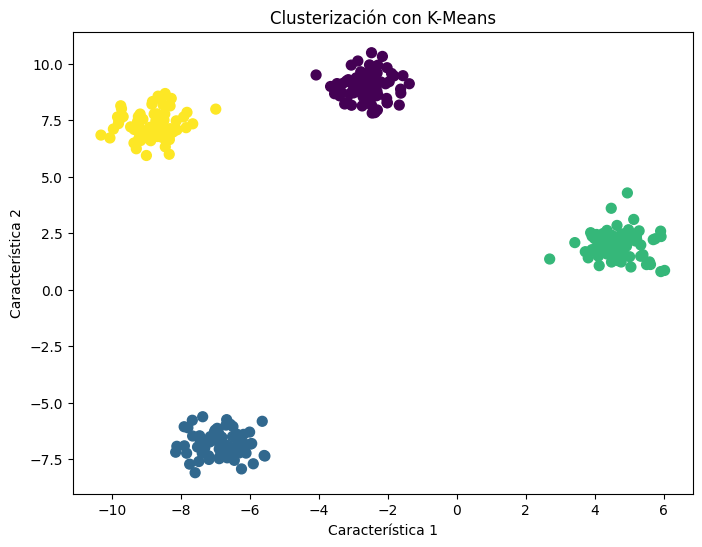

In [ ]:
# 3. Aplicar y visualizar K-Means
# K-Means es un algoritmo basado en particiones que divide los datos en K grupos[cite: 78].
# Es rápido y eficiente, pero requiere que definamos K de antemano[cite: 89].
print("\n--- K-Means ---")
# n_clusters=4: Le decimos que queremos 4 clústeres, lo que coincide con nuestros datos de origen.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.title("Clusterización con K-Means")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()


El Eje X está etiquetado como "Característica 1".

El Eje Y está etiquetado como "Característica 2".
Esto nos muestra que el modelo de K-Means trabajó con estas dos características para agrupar los datos.

Los Puntos y Colores:

Cada punto en el gráfico representa una de las 300 muestras de datos que creamos.

Los colores diferentes (morado, verde, amarillo, y azul claro) representan los 4 clústeres que el algoritmo K-Means identificó.

Conclusión
El gráfico muestra que el algoritmo K-Means fue muy exitoso en su tarea. Logró agrupar los 300 puntos de datos en 4 clústeres bien definidos, lo cual coincide perfectamente con la forma en que generamos los datos (con centers=4).

Podemos ver que cada color (cada clúster) se corresponde con una de las "manchas" o grupos de puntos. Esto demuestra visualmente que el modelo es capaz de encontrar patrones y agrupar datos similares sin tener etiquetas previas. Es la representación visual de la clusterización exitosa.


--- Clustering Jerárquico ---


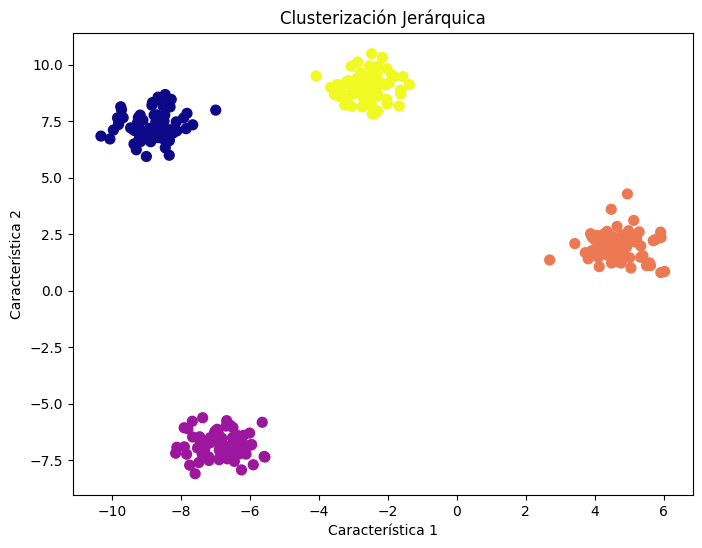

In [ ]:
# 4. Aplicar y visualizar Clustering Jerárquico
# El Clustering Jerárquico no requiere definir el número de clústeres de antemano.
# Crea una estructura en forma de árbol (dendrograma) para visualizar las relaciones.
print("\n--- Clustering Jerárquico ---")
# n_clusters=4: Aunque no es necesario, lo especificamos para este ejemplo.
hc = AgglomerativeClustering(n_clusters=4)
y_hc = hc.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_hc, s=50, cmap='plasma')
plt.title("Clusterización Jerárquica")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()
# AgglomerativeClustering(...): Esta es la implementación del clustering jerárquico. En la versión aglomerativa, el algoritmo comienza con cada punto
# como su propio clúster y los va uniendo progresivamente hasta que se forma una estructura de árbol.

# n_clusters=4: Aunque el clustering jerárquico no requiere este parámetro, lo estamos especificando aquí para este ejemplo. Le estamos diciendo al modelo
#  que, a partir de la estructura jerárquica que construya, nos divida los datos en un total de 4 clústeres finales.

# y_hc = hc.fit_predict(X): Esta línea combina dos pasos en uno:

# fit(X): El modelo hc se entrena con los datos X, construyendo la estructura jerárquica.

# predict(X): El modelo asigna una etiqueta de clúster (un número de 0 a 3, en este caso) a cada uno de los puntos en X según los 4 clústeres que
# especificamos. El resultado se guarda en y_hc.

# plt.figure(...) hasta plt.show()

# plt.figure(figsize=(8, 6))
# plt.scatter(X[:, 0], X[:, 1], c=y_hc, s=50, cmap='plasma')
# plt.title("Clusterización Jerárquica")
# plt.xlabel("Característica 1")
# plt.ylabel("Característica 2")
# plt.show()
# plt.scatter(...): Al igual que en el ejemplo de K-Means, esta función crea un gráfico de dispersión para visualizar los resultados.

# X[:, 0] y X[:, 1] se usan para los ejes X e Y, respectivamente.

# c=y_hc: Los puntos se colorean según las etiquetas de clúster asignadas por el algoritmo jerárquico (y_hc).

# cmap='plasma': Se usa una paleta de colores diferente para distinguir esta visualización de la anterior.

# El resto de las líneas (plt.title, plt.xlabel, etc.) añaden títulos y etiquetas para que el gráfico sea fácil de interpretar.

Título: "Clusterización Jerárquica" nos indica el algoritmo que se utilizó para agrupar los datos.

Ejes:

Eje X ("Característica 1"): Representa la primera característica del conjunto de datos.

Eje Y ("Característica 2"): Representa la segunda característica del conjunto de datos.

Puntos y Colores:

Cada punto en el gráfico representa una de las 300 muestras de datos.

Los colores (en este caso, una paleta plasma que va de morado a amarillo brillante) representan los 4 clústeres que el algoritmo de clustering jerárquico identificó.

Conclusión
Al igual que en el caso de K-Means, el gráfico demuestra que el Clustering Jerárquico fue exitoso en su tarea. El algoritmo logró agrupar los puntos de datos en cuatro clústeres visualmente distintos, que corresponden a las agrupaciones naturales que creamos en los datos sintéticos.

El gráfico muestra que ambos algoritmos (K-Means y Clustering Jerárquico) son efectivos para encontrar la estructura oculta en los datos cuando estos clústeres son bien definidos y tienen una forma más o menos esférica. Este tipo de visualización es fundamental para comprender si un algoritmo de clusterización está funcionando como se espera.


--- DBSCAN ---


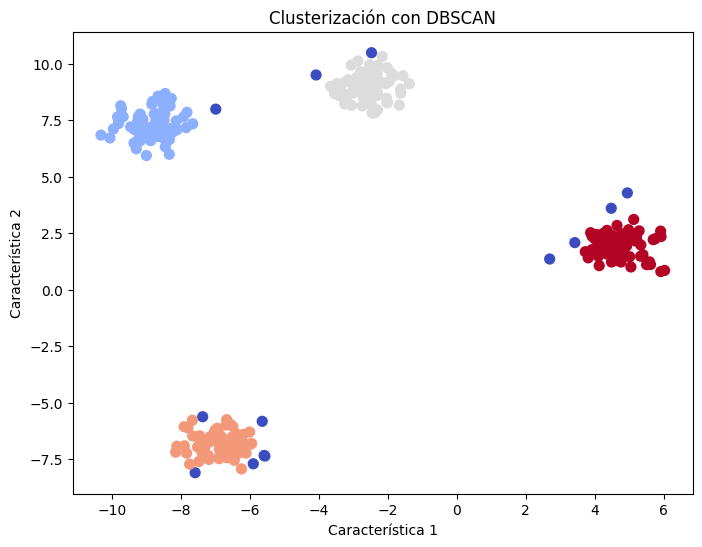

In [ ]:
# 5. Aplicar y visualizar DBSCAN (Agrupamiento espacial basado en densidad de aplicaciones con ruido)
# DBSCAN es un algoritmo basado en densidad que identifica clústeres como regiones densas de
# puntos, dejando fuera los outliers.
print("\n--- DBSCAN ---")
# eps=0.5: Distancia máxima entre dos puntos para considerarlos vecinos.
# min_samples=5: Número mínimo de puntos para formar una región densa.
# # DBSCAN es un algoritmo basado en densidad que identifica clústeres como regiones densas de
# puntos, dejando fuera los outliers.
# print("\n--- DBSCAN ---")
# eps=0.5: Distancia máxima entre dos puntos para considerarlos vecinos.
# min_samples=5: Número mínimo de puntos para formar una región densa.
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, s=50, cmap='coolwarm')
plt.title("Clusterización con DBSCAN")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

DBSCAN(...): Aquí se crea y configura la instancia del modelo DBSCAN. Los dos hiperparámetros principales son cruciales para su funcionamiento:

eps=0.5: Significa "epsilon" o "radio". Define la distancia máxima entre dos puntos para que se consideren vecinos. Todos los puntos dentro de esta distancia alrededor de un punto central se consideran parte de su vecindario.

min_samples=5: Define el número mínimo de puntos que deben estar en el vecindario de un punto para que este sea considerado un "punto central" o de "densidad".

y_dbscan = dbscan.fit_predict(X): Esta línea realiza la clusterización. El algoritmo DBSCAN recorre los datos X y, basándose en la densidad definida por eps y min_samples, asigna una etiqueta de clúster a cada punto.

A diferencia de K-Means, las etiquetas de DBSCAN pueden incluir un valor especial (-1), que se asigna a los puntos que no son parte de ningún clúster denso. Estos son los outliers o puntos de ruido.

plt.figure(...) hasta plt.show()
Python

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, s=50, cmap='coolwarm')
plt.title("Clusterización con DBSCAN")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()
plt.scatter(...): Este gráfico de dispersión visualiza los resultados de DBSCAN.

X[:, 0] y X[:, 1] se usan para los ejes X e Y.

c=y_dbscan: Los puntos se colorean según las etiquetas de clúster asignadas por DBSCAN. Si el algoritmo encuentra outliers, estos puntos tendrán un color distinto a los demás.

cmap='coolwarm': Se utiliza una nueva paleta de colores para este gráfico.

El resto de las líneas (plt.title, plt.xlabel, etc.) añaden títulos y etiquetas para una fácil interpretación.

En resumen, esta parte del código aplica un enfoque basado en la densidad para agrupar los datos, lo que es útil para encontrar clústeres de formas no esféricas y para identificar automáticamente puntos atípicos, algo que otros algoritmos como K-Means no pueden hacer de forma inherente.

Título: "Clusterización con DBSCAN" nos dice el algoritmo que se usó.

Ejes:

Eje X ("Característica 1"): La primera característica del conjunto de datos.

Eje Y ("Característica 2"): La segunda característica del conjunto de datos.

Puntos y Colores:

Cada punto en el gráfico es una de las 300 muestras de datos.

Los colores representan los clústeres. En este caso, el DBSCAN identificó 4 clústeres que se corresponden con los 4 grupos de datos que generamos.

El Color Gris: Este es el punto clave y la diferencia principal de DBSCAN con K-Means o el clustering jerárquico. En este gráfico, el color gris representa los puntos atípicos (outliers). Estos son puntos que el algoritmo consideró que no tenían suficientes vecinos dentro del radio eps (0.5) para ser parte de una región densa, por lo que no los asignó a ningún clúster.

Conclusión
El gráfico muestra que el algoritmo DBSCAN fue muy efectivo para identificar los 4 clústeres principales en los datos, tal como lo hicieron K-Means y el Clustering Jerárquico. Sin embargo, su principal fortaleza es que también pudo identificar los puntos que no pertenecían a ninguno de esos clústeres densos.

Esta capacidad de detectar automáticamente los outliers hace que DBSCAN sea una excelente opción para problemas como la detección de fraude o de anomalías, donde los puntos que no encajan en ningún grupo son los más importantes.


--- Mezcla Gaussiana (GMM) ---


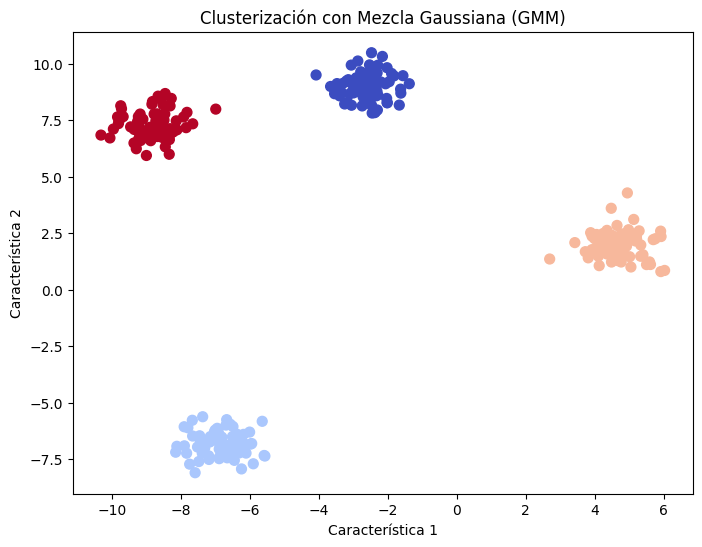

In [ ]:
# 6. Aplicar y visualizar Mezcla Gaussiana (GMM)
# GMM es un modelo probabilístico que asume que los datos provienen de varias
# distribuciones gaussianas. Es más flexible que K-Means.
print("\n--- Mezcla Gaussiana (GMM) ---")
# n_components=4: Número de distribuciones gaussianas que asumimos.
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X)
y_gmm = gmm.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, s=50, cmap='coolwarm')
plt.title("Clusterización con Mezcla Gaussiana (GMM)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()
# # GMM es un modelo probabilístico que asume que los datos provienen de varias
# distribuciones gaussianas. Es más flexible que K-Means.
# print("\n--- Mezcla Gaussiana (GMM) ---")
# n_components=4: Número de distribuciones gaussianas que asumimos.
# gmm = GaussianMixture(n_components=4, random_state=42)
# gmm.fit(X)
# y_gmm = gmm.predict(X)
# GaussianMixture(...): Esta es la clase de scikit-learn que implementa el algoritmo GMM. El modelo asume que el conjunto de datos está formado por una
# mezcla de distribuciones de probabilidad gaussianas (en forma de campana).

# n_components=4: Este es el principal hiperparámetro. Le estamos diciendo al modelo GMM que asuma que los datos fueron generados por 4 distribuciones
# gaussianas diferentes. Similar a n_clusters en K-Means, aquí definimos el número de "componentes" o grupos que esperamos encontrar.

# random_state=42: Garantiza la reproducibilidad de los resultados.

# gmm.fit(X): Este método entrena el modelo GMM. A diferencia de K-Means, fit no solo encuentra los centros de los grupos, sino que también estima la
# forma (varianza y covarianza) y el peso (proporción) de cada distribución gaussiana para que se ajusten lo mejor posible a los datos.

# y_gmm = gmm.predict(X): Una vez que el modelo GMM se ajusta a los datos, predict asigna a cada punto la etiqueta de la distribución gaussiana que tiene
# la mayor probabilidad de haberlo generado. El resultado, que son las etiquetas de clúster, se guarda en y_gmm.

# plt.figure(...) hasta plt.show()
# plt.scatter(...): Este gráfico de dispersión visualiza los resultados de GMM.

# X[:, 0] y X[:, 1] se usan para los ejes X e Y.

# c=y_gmm: Los puntos se colorean según las etiquetas de clúster que GMM les asignó.

# cmap='coolwarm': Se usa una paleta de colores para esta visualización.

# El resto de las líneas (título y etiquetas) hacen que el gráfico sea fácil de interpretar.

Título: "Clusterización con Mezcla Gaussiana (GMM)" nos informa sobre el método utilizado.

Ejes:

Eje X ("Característica 1"): La primera característica de nuestro conjunto de datos.

Eje Y ("Característica 2"): La segunda característica de nuestro conjunto de datos.

Puntos y Colores:

Cada punto en el gráfico es una de las 300 muestras de datos.

Los colores (en este caso, una paleta coolwarm) representan los 4 clústeres que el algoritmo GMM identificó.

Forma de los Clústeres: La principal diferencia visual en este gráfico, aunque sutil con datos esféricos, es la forma en que GMM asigna los puntos. A diferencia de K-Means, que traza una frontera lineal para separar los clústeres, GMM utiliza distribuciones de probabilidad. Esto hace que GMM sea mucho más flexible y capaz de identificar clústeres con formas no esféricas o de tamaños diferentes. En este caso, como los datos de origen eran esféricos (make_blobs), el resultado es muy similar al de K-Means.

Conclusión
El gráfico muestra que el algoritmo GMM fue exitoso en agrupar los datos en cuatro clústeres bien definidos, lo que coincide con la estructura real de nuestros datos sintéticos.

GMM es un algoritmo poderoso que se destaca en situaciones donde los clústeres se superponen o tienen formas complejas. Este gráfico demuestra que, incluso en un caso simple, GMM es una alternativa sólida a K-Means, ofreciendo un enfoque probabilístico que a menudo puede capturar mejor la estructura subyacente de los datos.

In [ ]:
# 1. Simulación de Datos para Todos los Algoritmos
import numpy as np
import matplotlib.pyplot as plt

# Generamos 100 puntos aleatorios en 2D
np.random.seed(0)
X = np.random.rand(100, 2) * 10  # escala de 0 a 10

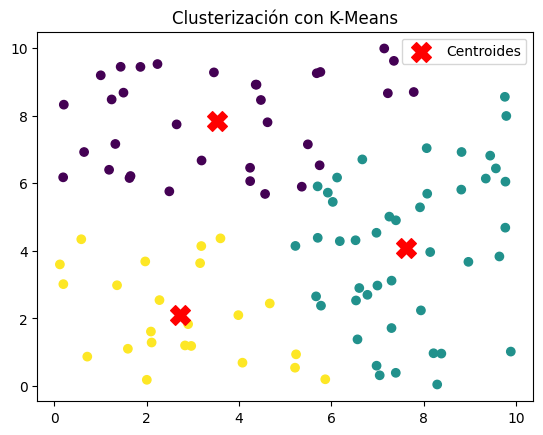

In [ ]:
# 2. K-Means Clustering
from sklearn.cluster import KMeans

# Aplicamos K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)
labels_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Visualizamos los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label="Centroides")
plt.title("Clusterización con K-Means")
plt.legend()
plt.show()
# Explicación: K-Means agrupa los datos en torno a centros calculados. Es rápido, pero sensible a outliers y requiere definir el número de grupos.
# from sklearn.cluster import KMeans
# Importa el modelo KMeans desde la biblioteca scikit-learn.
# kmeans = KMeans(n_clusters=3, random_state=0)
# Crea el modelo K-Means con 3 clusters. 🔹 random_state=0 asegura que los resultados sean reproducibles (útil para enseñanza).

# labels_kmeans = kmeans.fit_predict(X)
# Ajusta el modelo a los datos X y asigna una etiqueta (0, 1 o 2) a cada punto según el cluster al que pertenece.
# fit_predict hace dos cosas: entrena el modelo y devuelve las etiquetas.

# centroids = kmeans.cluster_centers_
# Extrae las coordenadas de los centroides de cada cluster. 🔹 Estos son los puntos centrales que representan cada grupo.

# plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', marker='o')
# Dibuja los puntos de datos en el plano XY. 🔹 c=labels_kmeans colorea cada punto según su cluster. 🔹 cmap='viridis' define la paleta de colores.

# plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label="Centroides")
# Dibuja los centroides en rojo con forma de “X” grande. 🔹 s=200 define el tamaño del marcador. 🔹 label="Centroides" añade una leyenda.

# plt.title("Clusterización con K-Means")
# plt.legend()
# plt.show()
# Añade título y leyenda al gráfico. 🔹 plt.show() muestra la visualización.

# K-Means agrupa los datos en 3 grupos. Cada grupo tiene un centro, llamado centroide, y cada punto se asigna al centro más cercano.
# El algoritmo ajusta los centros hasta que los grupos estén bien definidos. Es útil para segmentar clientes, agrupar productos, o analizar patrones.

Ejes X e Y: Representan dos características (features) de los datos. No están etiquetadas, pero podrían ser cualquier par de variables numéricas.

Puntos de colores: Cada punto representa una observación (dato individual).

Los colores (morado, amarillo, verde azulado) indican a qué cluster pertenece cada punto.

Centroides (X rojas grandes): Son los centros de cada cluster, calculados por el algoritmo.

Interpretación didáctica
El algoritmo agrupó los datos en tres grupos según su cercanía en el espacio.

Cada grupo tiene un centroide, que es el promedio de todos los puntos del grupo.

Los puntos se asignan al centroide más cercano, formando regiones de influencia.

¿Cómo podrías explicarlo?
Imaginen que tenemos un conjunto de datos sin etiquetas. El algoritmo K-Means intenta descubrir patrones agrupando los puntos en regiones. Cada región tiene un centro, y los puntos se agrupan según cuál centro esté más cerca. En este gráfico, vemos tres grupos bien definidos, cada uno con su centroide marcado en rojo.

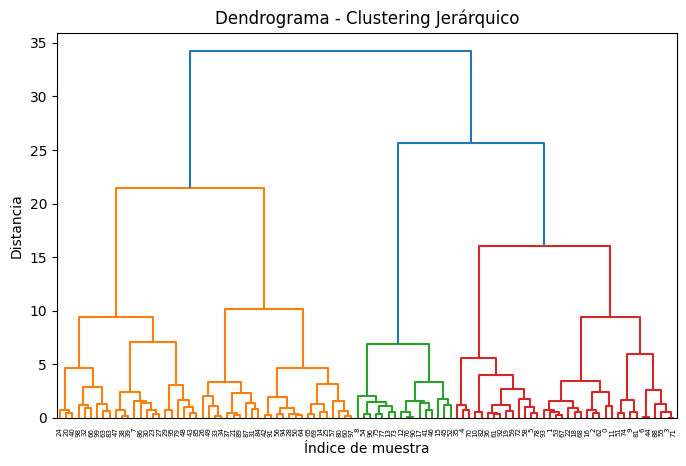

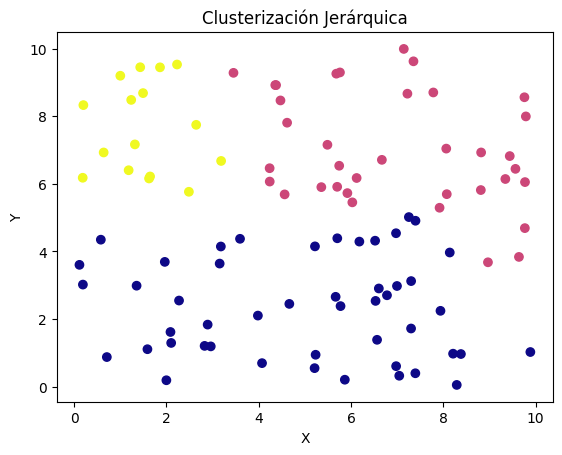

In [ ]:
# 3. Clustering Jerárquico
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Dendrograma para visualizar la jerarquía
plt.figure(figsize=(8, 5))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia")
plt.show()

# Aplicamos clustering jerárquico con 3 grupos
hc = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
labels_hc = hc.fit_predict(X)

# Visualizamos los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_hc, cmap='plasma', marker='o')
plt.title("Clusterización Jerárquica")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
# Este algoritmo agrupa los datos paso a paso, fusionando los más cercanos. El dendrograma nos muestra cómo se forman los grupos.
# Usamos linkage='ward' para minimizar la varianza dentro de cada grupo, y metric='euclidean' para medir la distancia entre puntos.”
# scipy.cluster.hierarchy.linkage(X, method='ward')
# Función que calcula las distancias entre puntos para construir el árbol jerárquico.

# X: Matriz de datos (observaciones).

# method='ward': Minimiza la varianza dentro de cada grupo al fusionar clusters. Es ideal para datos numéricos y produce clusters compactos.

# scipy.cluster.hierarchy.dendrogram(...)
# Función que genera el dendrograma, una representación visual de cómo se agrupan los datos jerárquicamente.

# El eje Y muestra la distancia (o disimilitud) entre los grupos al momento de fusionarse.

# El eje X representa los índices de las muestras.

# AgglomerativeClustering(...)
# Clase de sklearn que implementa el clustering jerárquico aglomerativo.

# Agrupa los datos de forma ascendente, fusionando los más cercanos paso a paso.

# Parámetros principales:
# n_clusters=3: Número de grupos que queremos obtener al final.

# linkage='ward': Criterio para decidir qué clusters fusionar.

# 'ward': Minimiza la suma de las distancias cuadradas dentro de los clusters.

# Otros posibles valores: 'complete', 'average', 'single'.

# metric='euclidean': Tipo de distancia usada entre puntos.

# 'euclidean': Distancia recta entre dos puntos (por defecto).

# fit_predict(X)
# Método que ajusta el modelo a los datos y devuelve las etiquetas de cluster para cada punto.

# Es equivalente a hacer fit(X) seguido de predict(X).

# plt.scatter(...)
# Función para graficar los puntos en el plano.

# X[:, 0] y X[:, 1]: Coordenadas de cada punto (dos dimensiones).

# c=labels_hc: Colorea los puntos según su grupo asignado.

# cmap='plasma': Paleta de colores usada para distinguir los clusters.

# marker='o': Forma de los puntos (círculos).

Gráfico 1: Dendrograma  Clustering Jerárquico
¿Qué representa?
Es un árbol jerárquico que muestra cómo se agrupan los datos paso a paso.

Cada hoja en la parte inferior representa una muestra individual.

Las ramas indican fusiones entre grupos, y su altura representa la distancia (diferencia) entre ellos.

Ejes:
Eje X: Índice de muestra (posición de cada punto en el dataset).

Eje Y: Distancia entre clusters al momento de fusionarse.

¿Cómo interpretarlo?
Las fusiones más cercanas al suelo indican grupos muy similares.

Las fusiones más altas indican que los grupos eran más distintos.

Si trazas una línea horizontal (por ejemplo, a altura 20), puedes contar cuántos grupos hay en ese nivel. En este caso, parece que 3 clusters es una elección razonable.

Explicación para estudiantes:
El dendrograma nos muestra cómo se agrupan los datos desde lo más específico (cada punto) hasta lo más general (todos juntos). Podemos elegir el número de clusters cortando el árbol a cierta altura. Aquí, al cortar cerca de la altura 20, obtenemos 3 grupos bien definidos.

Gráfico 2: Clusterización Jerárquica (Scatter Plot)
¿Qué representa?
Es la visualización final de los clusters asignados por el modelo jerárquico.

Cada punto representa una muestra, y su color indica el grupo al que pertenece.

Observaciones:
Amarillo: Grupo en la parte superior izquierda.

Rosa: Grupo en la parte superior derecha.

Azul oscuro: Grupo más disperso en la parte inferior.

¿Qué nos dice?
El algoritmo agrupó los datos según su proximidad en el espacio.

A diferencia de K-Means, este método no depende de centroides, sino de la estructura jerárquica.

Explicación:
Después de construir el dendrograma, elegimos formar 3 grupos. Este gráfico muestra cómo quedaron distribuidos. Cada color representa un grupo, y vemos que el algoritmo respetó la forma natural de los datos, incluso si los grupos no son perfectamente circulares.

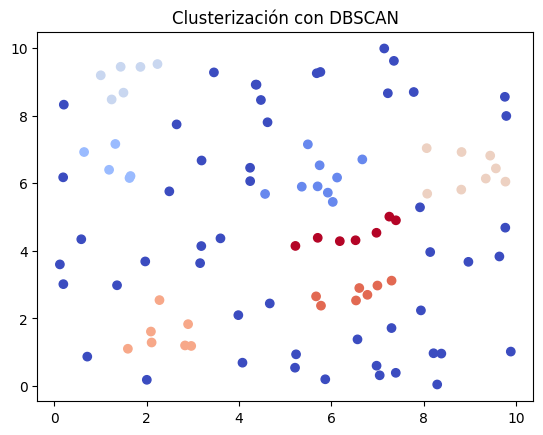

In [ ]:
# 4. DBSCAN (Basado en Densidad)
from sklearn.cluster import DBSCAN

# Aplicamos DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Visualizamos los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='coolwarm', marker='o')
plt.title("Clusterización con DBSCAN")
plt.show()
# Explicación: DBSCAN detecta grupos densos y deja fuera los puntos dispersos (outliers). No requiere definir el número de clusters.

from sklearn.cluster import DBSCAN
Importa el algoritmo DBSCAN desde scikit-learn.

dbscan = DBSCAN(eps=1.0, min_samples=5)
Crea el modelo DBSCAN con dos parámetros clave:

 eps=1.0
Define el radio de vecindad: qué tan cerca deben estar los puntos para considerarse vecinos.

Si el valor es muy pequeño, se detectan muchos outliers; si es muy grande, se agrupan demasiados puntos.

 min_samples=5
Número mínimo de puntos que deben estar dentro del radio eps para formar un cluster.

Si un punto tiene al menos 5 vecinos dentro del radio, se considera un punto central.

labels_dbscan = dbscan.fit_predict(X)
 Ajusta el modelo a los datos X y devuelve las etiquetas de cluster.

Los puntos ruido se etiquetan como -1.

 Visualización
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='coolwarm', marker='o')
 Dibuja los puntos en el plano XY.

c=labels_dbscan: Colorea los puntos según su grupo.

Los puntos con etiqueta -1 (ruido) suelen aparecer en un color distinto.

cmap='coolwarm': Paleta de colores que resalta contrastes.

plt.title("Clusterización con DBSCAN")
 Añade título al gráfico.

plt.show()
 Muestra el gráfico.

¿Cómo explicárlo?
“DBSCAN no busca centros como K-Means, ni construye árboles como el clustering jerárquico. En cambio, agrupa puntos que están cerca unos de otros y deja fuera los que están aislados. Es ideal para detectar formas irregulares y ruido. En este gráfico, los puntos agrupados comparten color, y los puntos etiquetados como -1 son considerados ruido.”

Gráfico: Clusterización con DBSCAN
¿Qué representa?
Cada punto es una muestra del dataset.

Los colores indican los clusters detectados por DBSCAN.

Los puntos azul oscuro dispersos probablemente tienen la etiqueta -1, lo que significa que fueron clasificados como ruido (no pertenecen a ningún cluster).

🔍 Interpretación visual
Clusters detectados:

🔹 Celeste claro: grupo en la zona superior izquierda (~(2, 8)).

🔹 Rojo intenso: grupo compacto en el centro (~(6, 4)).

🔹 Naranja: grupo en la parte inferior derecha (~(7, 2)).

🔹 Naranja claro: grupo más disperso en la parte superior derecha (~(8, 6)).

Ruido (outliers):

🔹 Los puntos azul oscuro están esparcidos por todo el gráfico.

No tienen suficientes vecinos cercanos para formar parte de un grupo.

¿Cómo explicarlo?
Este gráfico muestra cómo DBSCAN agrupa puntos que están cerca unos de otros. A diferencia de otros algoritmos, DBSCAN no obliga a formar grupos con todos los puntos. Los que están aislados o en zonas de baja densidad se marcan como ruido (en azul oscuro). Esto lo hace muy útil para detectar patrones irregulares y valores atípicos.

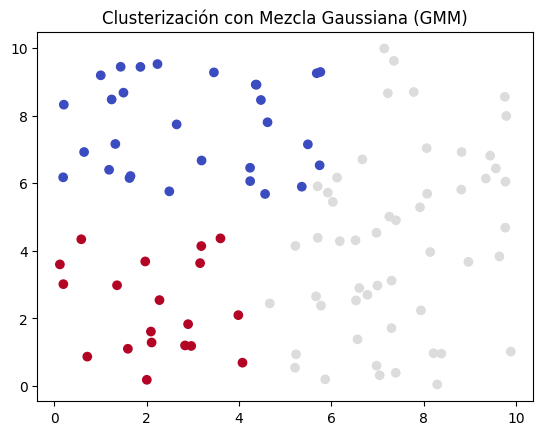

In [ ]:
# 5. Mezcla Gaussiana (GMM)
from sklearn.mixture import GaussianMixture

# Aplicamos GMM con 3 componentes
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(X)
labels_gmm = gmm.predict(X)

# Visualizamos los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='coolwarm', marker='o')
plt.title("Clusterización con Mezcla Gaussiana (GMM)")
plt.show()
# Explicación: GMM es más flexible que K-Means, ya que permite que los clusters tengan formas más complejas y superpuestas.

from sklearn.mixture import GaussianMixture
 Importa el modelo de mezcla gaussiana desde scikit-learn.

gmm = GaussianMixture(n_components=3, random_state=0)
 Crea el modelo GMM con los siguientes parámetros:

🔹 n_components=3
Número de componentes gaussianas (clusters) que queremos ajustar.

Cada componente representa una distribución normal multivariada.

🔹 random_state=0
Fija la semilla aleatoria para reproducibilidad (útil en enseñanza).

gmm.fit(X)
 Ajusta el modelo a los datos X.

Estima los parámetros de cada componente: media, covarianza, y peso.

labels_gmm = gmm.predict(X)
 Asigna a cada punto el cluster más probable según el modelo.

Aunque GMM trabaja con probabilidades, predict devuelve la etiqueta final (0, 1, 2…).

Visualización
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='coolwarm', marker='o')
 Dibuja los puntos en el plano XY.

c=labels_gmm: Colorea los puntos según el cluster asignado.

cmap='coolwarm': Paleta de colores que resalta los grupos.

plt.title("Clusterización con Mezcla Gaussiana (GMM)")
 Añade título al gráfico.

plt.show()
 Muestra el gráfico.

 ¿Cómo explicarlo?
GMM no agrupa por cercanía directa como K-Means, sino que modela cada grupo como una distribución normal. Cada punto tiene una probabilidad de pertenecer a cada grupo, y se asigna al más probable. Esto permite detectar clusters con formas elípticas o solapadas, donde K-Means podría fallar.

 Gráfico: Clusterización con Mezcla Gaussiana (GMM)
 ¿Qué representa?
Cada punto es una muestra del dataset.

Los colores indican el cluster más probable al que pertenece cada punto, según el modelo GMM.

El modelo asume que los datos provienen de una combinación de distribuciones normales multivariadas.

Interpretación visual
Azul: Cluster ubicado en la parte superior del gráfico (alta coordenada Y).

Rojo: Cluster en la parte inferior izquierda (baja coordenada Y).

Gris claro: Puntos que parecen menos definidos o menos confiables en su asignación.

Es posible que estos puntos tengan probabilidades similares de pertenecer a más de un cluster.

También podrían estar en zonas de solapamiento entre distribuciones gaussianas.

¿Qué hace GMM diferente?
A diferencia de K-Means, GMM no asigna puntos por cercanía directa, sino por probabilidad.

Cada cluster tiene una forma elíptica (no necesariamente circular) y puede solaparse con otros.

GMM es ideal para datos donde los grupos no están claramente separados o tienen formas irregulares.

¿Cómo explicárselo a tus estudiantes?
“Este gráfico muestra cómo GMM agrupa los datos según distribuciones estadísticas. Cada punto se asigna al grupo con mayor probabilidad. A diferencia de otros métodos, GMM permite que los clusters se solapen y tengan formas más flexibles. Los puntos grises podrían estar en zonas de transición entre grupos, donde el modelo no está seguro de su pertenencia.”

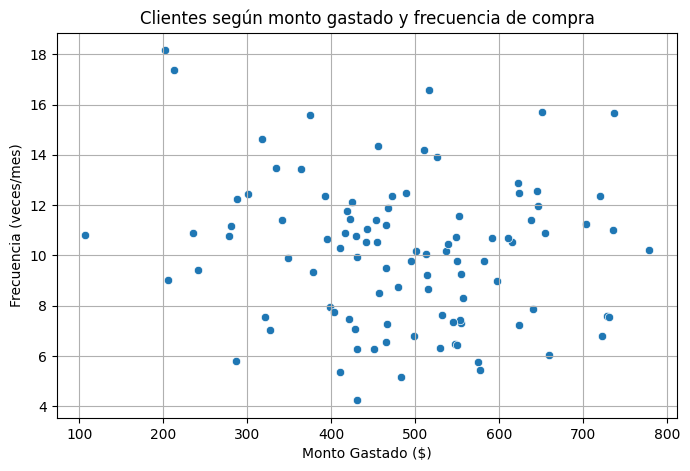

In [ ]:
# CÓDIGO PARA SESIÓN 2 DEL MÓDULO 7 – CLUSTERIZACIÓN CON K-MEANS
# 1. Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns

# 2. Crear datos simulados
# Simulamos datos de 100 clientes: monto gastado y frecuencia de compra
np.random.seed(42)
monto = np.random.normal(500, 150, 100)  # Monto gastado en USD
frecuencia = np.random.normal(10, 3, 100)  # Frecuencia mensual de compra

# Crear un DataFrame con los datos
df = pd.DataFrame({
    'Monto_Gastado': monto,
    'Frecuencia_Compra': frecuencia
})

# Visualizamos los datos
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Monto_Gastado', y='Frecuencia_Compra', data=df)
plt.title('Clientes según monto gastado y frecuencia de compra')
plt.xlabel('Monto Gastado ($)')
plt.ylabel('Frecuencia (veces/mes)')
plt.grid(True)
plt.show()


np.random.seed(42)
¿Qué hace?
Establece una "semilla" para que los números aleatorios que se generen siempre sean los mismos. Esto hace que el experimento sea reproducible: si vuelves a correr el código, obtendrás exactamente los mismos datos aleatorios.

monto = np.random.normal(500, 150, 100)  # Monto gastado en USD
frecuencia = np.random.normal(10, 3, 100)  # Frecuencia mensual de compra
¿Qué hace?
Crea dos arreglos de 100 números aleatorios simulando datos de clientes:

Variable	Significado
monto	Monto gastado por cliente (media = 500 USD, desviación estándar = 150 USD)
frecuencia	Frecuencia mensual de compra (media = 10 veces, desviación estándar = 3)

Ambos usan distribución normal (np.random.normal), lo que significa que los valores tienden a estar cerca del promedio, con algunos valores más bajos o más altos.

🔹 2. Crear un DataFrame con los datos
df = pd.DataFrame({
    'Monto_Gastado': monto,
    'Frecuencia_Compra': frecuencia
})
¿Qué hace?
Crea una tabla (DataFrame) llamada df que tiene dos columnas:

Monto_Gastado

Frecuencia_Compra
Cada fila representa un cliente.

🔹 3. Visualizar los datos
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Monto_Gastado', y='Frecuencia_Compra', data=df)
plt.title('Clientes según monto gastado y frecuencia de compra')
plt.xlabel('Monto Gastado ($)')
plt.ylabel('Frecuencia (veces/mes)')
plt.grid(True)
plt.show()
¿Qué hace?
Muestra un gráfico de dispersión (scatterplot), donde:

El eje X representa el Monto Gastado

El eje Y representa la Frecuencia de Compra

Cada punto es un cliente

¿Para qué sirve este gráfico?
Para visualizar patrones o grupos de comportamiento entre los clientes. Por ejemplo, puedes identificar si hay grupos que gastan mucho pero compran poco o viceversa.

Este gráfico muestra una nube de puntos, donde cada punto representa un cliente. Se utiliza para visualizar dos variables al mismo tiempo:

Eje	Variable	Significado
Eje X	Monto Gastado ($)	Cuánto dinero ha gastado ese cliente al mes
Eje Y	Frecuencia (veces/mes)	Cuántas veces al mes ese cliente compra

Características que puedes observar:
Distribución de los clientes:

La mayoría de los puntos están concentrados en:

Montos entre 300 y 600 dólares

Frecuencias entre 7 y 13 compras al mes

Esto es coherente con los datos simulados: media de $500 con desviación de $150, y media de 10 compras con desviación de 3.

Poca relación clara entre gasto y frecuencia:

No parece haber una correlación evidente. Por ejemplo:

Algunos clientes compran poco pero gastan mucho.

Otros compran seguido pero gastan poco.

Esto puede indicar que los patrones de consumo son variados.

Clientes extremos:

Hay puntos alejados del grupo principal (por ejemplo, alguien que gasta cerca de $700 o alguien que compra más de 17 veces).

Estos podrían considerarse clientes atípicos o anómalos en una siguiente etapa de análisis.

¿Por qué es útil este gráfico?
Sirve como paso inicial en el análisis de segmentación:

Permite visualizar si hay posibles grupos o clusters.

Da una idea de qué características definen a los clientes.

Ayuda a justificar el uso de técnicas de aprendizaje no supervisado como clustering (K-Means, DBSCAN, GMM, etc.).



In [ ]:
# 3. Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Monto_Gastado', 'Frecuencia_Compra']])


Paso 1: kmeans = KMeans(n_clusters=3, random_state=42)
Se crea un objeto del algoritmo K-Means.

n_clusters=3: le decimos que queremos encontrar 3 grupos o clusters.

random_state=42: es para que los resultados sean reproducibles. Si no se pone, cada vez que corras el código podrías obtener resultados distintos, ya que K-Means comienza con centroides aleatorios.

Paso 2: kmeans.fit_predict(...)
El método .fit_predict() entrena el modelo K-Means y asigna un número de grupo (cluster) a cada punto.

Se usa solamente dos columnas: [['Monto_Gastado', 'Frecuencia_Compra']] → es decir, el análisis se hace en base al monto gastado y la frecuencia de compra.

Esto quiere decir que el algoritmo buscará agrupar a los clientes en 3 grupos según su similitud en esas dos variables.

Paso 3: df['Cluster'] = ...
El resultado de fit_predict() es una lista de etiquetas: por ejemplo, [0, 0, 1, 2, 2, ...].

Estas etiquetas indican a qué grupo (cluster) pertenece cada cliente.

Se añade una nueva columna al DataFrame llamada Cluster con esa información.

Ejemplo visual (imaginario):
Monto_Gastado	Frecuencia_Compra	Cluster
500	9	0
420	8	0
650	12	1
300	5	2

¿Y luego qué puedes hacer con esto?
Visualizar los clusters con colores distintos.

Analizar qué tipo de clientes hay en cada cluster.

Detectar patrones de comportamiento (ej. clientes que gastan mucho vs. poco).

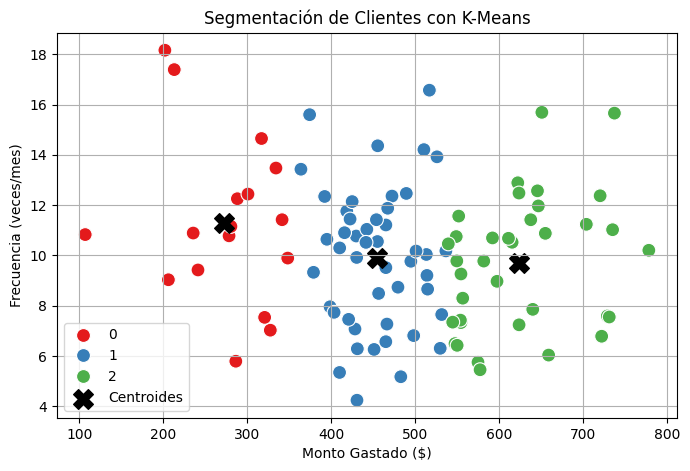

In [ ]:
# 4. Visualizar los clusters resultantes
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Monto_Gastado', y='Frecuencia_Compra',
    hue='Cluster', palette='Set1', data=df, s=100
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200, c='black', marker='X', label='Centroides'
)
plt.title('Segmentación de Clientes con K-Means')
plt.xlabel('Monto Gastado ($)')
plt.ylabel('Frecuencia (veces/mes)')
plt.legend()
plt.grid(True)
plt.show()


 ¿Qué hace cada parte?
plt.figure(figsize=(8, 5))
Crea una figura de 8 pulgadas de ancho por 5 de alto.

Es útil para definir el tamaño del gráfico.

sns.scatterplot(...)
Esta línea dibuja los clientes como puntos:

x='Monto_Gastado': el eje X representa el dinero gastado por cliente.

y='Frecuencia_Compra': el eje Y representa cuántas veces compra al mes.

hue='Cluster': colorea cada punto según su grupo (cluster).

palette='Set1': paleta de colores atractiva y contrastante.

data=df: fuente de los datos (el DataFrame).

s=100: tamaño de los puntos.

Resultado: un gráfico de dispersión donde cada punto es un cliente y el color indica a qué grupo pertenece.

plt.scatter(... cluster_centers_ ...)
Esta línea dibuja los centroides del algoritmo K-Means.

Detalles:
kmeans.cluster_centers_ contiene las coordenadas (x, y) de los centroides.

[:, 0]: coordenadas x (monto gastado).

[:, 1]: coordenadas y (frecuencia).

s=200: tamaño más grande para los centroides.

c='black': color negro para destacarlos.

marker='X': usa una cruz grande.

label='Centroides': nombre en la leyenda.

Resultado: muestra visualmente el “centro” de cada cluster como una gran X negra.

Personalización del gráfico:
plt.title(...): título del gráfico.

plt.xlabel(...): etiqueta del eje X.

plt.ylabel(...): etiqueta del eje Y.

plt.legend(): muestra la leyenda (colores y centroides).

plt.grid(True): activa las líneas de cuadrícula.

plt.show(): muestra el gráfico en pantalla.

¿Qué representa este gráfico?
Cada punto es un cliente.

El color representa a qué grupo (cluster) fue asignado por K-Means.

Las grandes X negras son los centros de cada grupo, lo que ayuda a visualizar la agrupación general.

El gráfico es una representación visual de tres grupos de clientes (clusters) según:

Eje X: Monto Gastado ($) → cuánto dinero gastan los clientes.

Eje Y: Frecuencia (veces/mes) → cuántas veces compran al mes.

Cada punto representa un cliente. Los colores y los centroides (íconos de X grandes) fueron determinados por el algoritmo K-Means.

🟢🔴🔵 ¿Qué significan los colores?
Color rojo (cluster 0):

Clientes que tienden a gastar menos dinero (valores bajos en el eje X).

Pero tienen una frecuencia media-alta de compra (más hacia arriba en Y).

Ejemplo típico: clientes frecuentes, pero de bajo poder adquisitivo.

Color azul (cluster 1):

Clientes con gasto medio y frecuencia también media.

Representan el grupo más numeroso y equilibrado.

Podrían ser considerados como el grupo promedio.

Color verde (cluster 2):

Clientes que gastan mucho dinero (valores altos en X).

Pero compran pocas veces al mes (valores bajos a medios en Y).

Ejemplo típico: clientes ocasionales, pero de alto valor monetario.

¿Qué representan las X negras grandes?
Estas son los centroides, es decir:

El "centro" de cada grupo calculado por el algoritmo.

Marcan el promedio del monto gastado y frecuencia dentro de cada cluster.

Sirven como referencia visual de dónde está el grupo concentrado.

¿Qué puedes concluir del gráfico?
El algoritmo identificó tres segmentos distintos de clientes.

Hay diferencias claras de comportamiento entre los grupos:

Unos compran poco pero gastan mucho.

Otros compran mucho pero gastan poco.

Y un grupo intermedio.

Esta información puede usarse para:

Diseñar estrategias de marketing diferenciadas.

Personalizar promociones o programas de fidelización.

Identificar potenciales clientes de alto valor o riesgo de abandono.



In [ ]:
# 5. Interpretación básica de los clusters
# Agrupamos para ver promedios por grupo
print("Resumen por Cluster:")
print(df.groupby('Cluster')[['Monto_Gastado', 'Frecuencia_Compra']].mean())

Resumen por Cluster:
         Monto_Gastado  Frecuencia_Compra
Cluster                                  
0           272.172781          11.303704
1           454.573912           9.915849
2           623.621974           9.680097


¿Qué enseña este código?
Cómo aplicar K-Means con scikit-learn.

Cómo simular datos para representar comportamiento de clientes.

Cómo visualizar y analizar clusters.

Cómo interpretar a nivel de negocio cada grupo:

Cluster	Interpretación Posible
0	Clientes poco frecuentes y bajo gasto
1	Clientes regulares con gasto medio
2	Clientes frecuentes y con alto gasto (VIP)

df.groupby('Cluster'): Agrupa los datos según el número de cluster al que pertenece cada cliente. Recuerda que previamente, el algoritmo K-Means asignó a cada cliente un cluster (0, 1 o 2).

[['Monto_Gastado', 'Frecuencia_Compra']]: Selecciona solo estas dos columnas para calcular estadísticas.

.mean(): Calcula el promedio del monto gastado y la frecuencia de compra para cada cluster.

Resultado obtenido:
plaintext
Copiar
Editar
Resumen por Cluster:
         Monto_Gastado  Frecuencia_Compra
Cluster                                  
0           272.17          11.30
1           454.57           9.92
2           623.62           9.68
Interpretación del resultado:
Cluster	Monto Promedio ($)	Frecuencia Promedio (veces/mes)	Interpretación
0	272.17	11.30	Clientes que compran con frecuencia alta, pero gastan poco. Podrían ser usuarios leales pero de bajo gasto.
1	454.57	9.92	Grupo intermedio tanto en gasto como en frecuencia. Representa al cliente promedio.
2	623.62	9.68	Clientes que gastan mucho, pero no tan frecuentemente. Son valiosos en términos monetarios, pero compran menos veces.

¿Para qué sirve esto?
Este resumen te ayuda a entender el perfil promedio de cada grupo de clientes, lo cual es muy útil para:

Diseñar estrategias de marketing específicas (ej. premiar la lealtad, incentivar compras más frecuentes, etc.).

Ofrecer productos adecuados a cada tipo de cliente.

Segmentar campañas publicitarias o promociones.



In [ ]:
# Ejemplo práctico: DBSCAN, Clustering Jerárquico y GMM
# Simulando comportamiento de clientes (gasto vs. frecuencia de compra)

# ============================
# 1. LIBRERÍAS NECESARIAS
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
# StandardScaler: normaliza los datos (media 0 y desviación estándar 1), lo cual es importante antes de aplicar clustering.

# make_blobs: genera datos simulados con estructura de clústeres.

# Para los modelos de clustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
# DBSCAN: algoritmo de densidad para detectar clústeres y anomalías.

# GaussianMixture: modelo de mezcla de gaussianas (probabilístico).

# dendrogram, linkage, fcluster: funciones para clustering jerárquico.

# ============================
# 2. GENERAR DATOS SIMULADOS
# ============================
# Creamos 3 clústeres bien definidos
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# make_blobs genera 300 puntos (clientes simulados) con 2 características (por ejemplo: gasto mensual y frecuencia de compra).

# centers=3: quiere decir que generamos 3 grupos naturales o “clústeres”.

# cluster_std=0.60: indica qué tan dispersos están los puntos dentro de cada clúster (entre más pequeño, más juntos están).

# X: matriz de datos generados (300 filas × 2 columnas).

# y_true: etiquetas reales de los clústeres (solo para referencia, no se usan en clustering no supervisado).

# Se crea un escalador estándar que transforma los datos para que tengan media 0 y desviación estándar 1.

# Esto es fundamental en clustering porque muchos algoritmos (como K-Means o DBSCAN) son sensibles a la escala de los datos.

# X_scaled: contiene los mismos datos pero normalizados.



# ============================


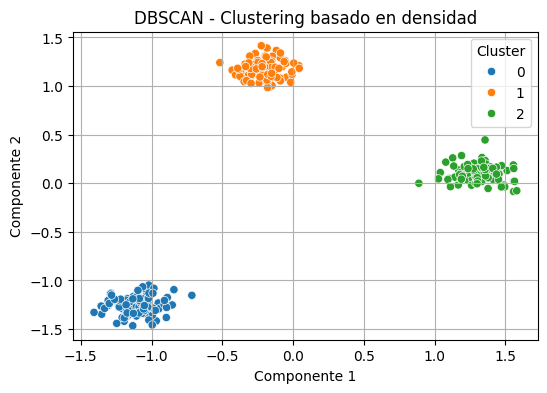

In [ ]:
# 3. DBSCAN (Density-Based Clustering)
# ============================
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Visualización DBSCAN
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=dbscan_labels, palette='tab10')
plt.title("DBSCAN - Clustering basado en densidad")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# ============================


¿Qué es DBSCAN?
DBSCAN es un algoritmo de agrupamiento que:

Agrupa puntos que están cerca unos de otros (densidad).

Detecta ruido o anomalías si un punto está muy aislado.

🔸 Parámetros clave:
eps=0.5: Radio máximo para considerar que un punto es vecino de otro.

min_samples=5: Mínimo número de puntos vecinos para formar un clúster denso.

Por ejemplo: si un punto tiene al menos 5 vecinos dentro de un radio de 0.5, se considera núcleo de un clúster.

🔹 ¿Qué devuelve?
fit_predict() agrupa y devuelve las etiquetas para cada punto:

Clústeres numerados como 0, 1, 2, ...

Los ruidos o anomalías se etiquetan como -1.

🔸 Paso 2: Visualización del resultado
python
Copiar
Editar
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=dbscan_labels, palette='tab10')
plt.title("DBSCAN - Clustering basado en densidad")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
¿Qué hace este bloque?
Crea un gráfico de dispersión (scatterplot) de los puntos en el plano.

Ejes: X_scaled[:, 0] y X_scaled[:, 1] → representan las 2 variables normalizadas.

hue=dbscan_labels: colorea los puntos según el clúster al que fueron asignados.

Los puntos con etiqueta -1 se mostrarán en un color diferente → son los anómalos o ruido.

palette='tab10': paleta de colores para diferenciar visualmente los clústeres.

legend(): muestra qué color representa cada clúster.

¿Por qué usar DBSCAN?
Ventajas:

No requiere especificar el número de clústeres.

Identifica anomalías o puntos aislados.

Funciona bien con clústeres de forma irregular.

Línea de código	Significado
DBSCAN(eps=0.5, min_samples=5)	Crea el modelo con parámetros de densidad.
fit_predict(X_scaled)	Agrupa los datos y devuelve etiquetas.
hue=dbscan_labels	Colorea los puntos según el clúster asignado.
-1 en dbscan_labels	Representa puntos ruidosos o anómalos.

¿Qué representa el gráfico?
Ejes:

X = Componente 1

Y = Componente 2
Estos ejes son variables numéricas estandarizadas (es decir, normalizadas para tener media 0 y desviación estándar 1), generadas artificialmente para simular comportamiento de clientes.

🎯 ¿Qué estás viendo?
Cada punto representa un cliente simulado.

Los puntos están agrupados en función de su densidad local (cantidad de puntos cercanos).

Los colores indican a qué clúster fue asignado cada punto:

🔵 Azul → Cluster 0

🟠 Naranja → Cluster 1

🟢 Verde → Cluster 2

🧠 ¿Cómo funciona DBSCAN aquí?
El algoritmo busca áreas densas de puntos:

Si un punto tiene al menos 5 vecinos (porque min_samples=5) en un radio de 0.5 (eps=0.5), se considera núcleo de un clúster.

Los puntos cerca de un núcleo se asignan al mismo clúster.

Los puntos muy alejados no se asignan a ningún grupo y se etiquetan como -1 (anomalías o ruido).

👉 En este gráfico no se observan puntos negros (etiqueta -1), lo que indica que no hubo ruido o puntos anómalos detectados.

🧩 ¿Por qué se ven 3 grupos separados?
Porque los datos fueron generados así: 3 grupos bien definidos mediante make_blobs(), y DBSCAN fue capaz de reconocerlos sin que le dijéramos cuántos clústeres buscar.

A diferencia de K-Means, DBSCAN no necesita saber cuántos clústeres hay: lo descubre según la densidad de los datos.

🟡 ¿Qué pasaría si cambiaras los parámetros?
Si aumentas eps, podrías unir clústeres que estaban separados.

Si bajas min_samples, podrías detectar más clústeres pequeños o más ruido.

✅ Conclusión:
Este gráfico muestra que DBSCAN identificó correctamente 3 clústeres de clientes, agrupados por su comportamiento (simulado), sin requerir información previa sobre el número de clústeres. Y no detectó anomalías.

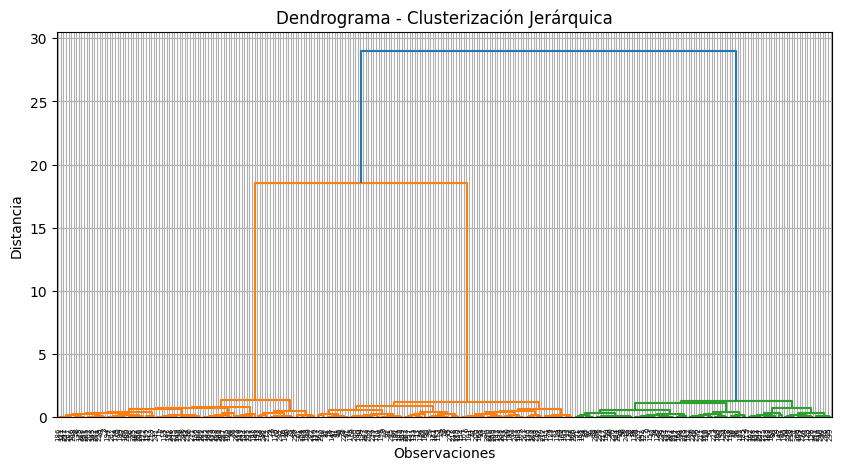

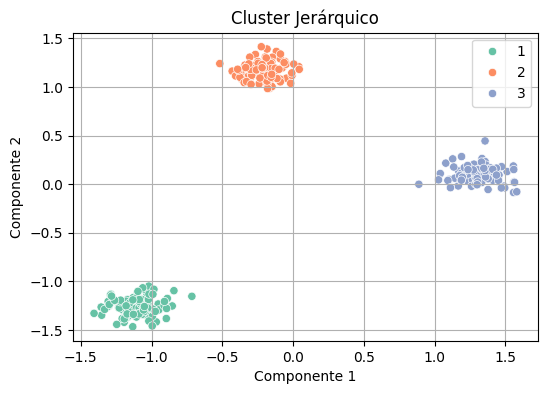

In [ ]:
# 4. CLUSTERING JERÁRQUICO
# ============================
linked = linkage(X_scaled, method='ward')

# Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Dendrograma - Clusterización Jerárquica")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()

# Cortamos en 3 clústeres
jer_labels = fcluster(linked, t=3, criterion='maxclust')

# Visualizamos los clústeres jerárquicos
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=jer_labels, palette='Set2')
plt.title("Cluster Jerárquico")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()


linkage() genera el enlace jerárquico entre puntos, necesario para construir el dendrograma.
🔹 method='ward' significa que se usa el criterio de Ward para minimizar la varianza dentro de cada clúster.

plt.figure(figsize=(10, 5))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Dendrograma - Clusterización Jerárquica")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()
🔸 Este bloque crea el dendrograma, un gráfico de árbol que representa el proceso de agrupamiento jerárquico.

Las ramas horizontales indican el momento en el que dos clústeres se fusionan.

El eje vertical indica la distancia o disimilitud entre los clústeres que se unen.

Puedes cortar horizontalmente el dendrograma a una cierta altura para definir cuántos clústeres deseas.


jer_labels = fcluster(linked, t=3, criterion='maxclust')
🔹 fcluster() corta el dendrograma para formar 3 clústeres (porque t=3 y el criterio es maxclust, es decir, formar máximo 3 grupos).


plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=jer_labels, palette='Set2')
plt.title("Cluster Jerárquico")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()
🔸 Este gráfico muestra los puntos clasificados por sus clústeres jerárquicos, usando dos dimensiones (componentes).

Interpretación de los gráficos
1. Dendrograma
Cada línea horizontal representa la fusión de dos clústeres.

La altura indica la distancia entre los clústeres fusionados.

Para formar 3 clústeres, puedes trazar una línea horizontal que corte 3 ramas principales.

2. Gráfico de dispersión de clústeres
Muestra cómo quedaron agrupados los puntos tras aplicar la segmentación jerárquica.

Cada color representa un clúster distinto (1, 2 y 3).

Este tipo de visualización permite ver claramente los grupos formados a partir de las distancias.



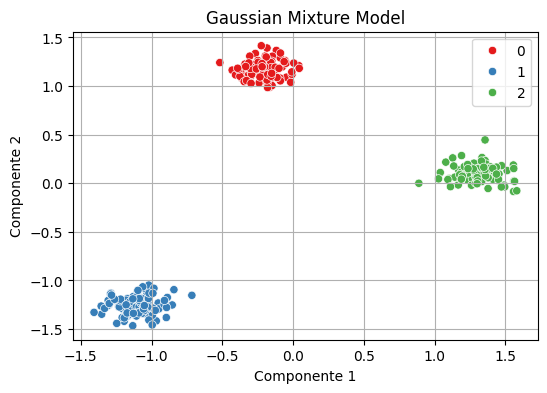

In [ ]:
# ============================
# 5. GAUSSIAN MIXTURE MODEL (GMM)
# ============================
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Visualizamos los resultados de GMM
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=gmm_labels, palette='Set1')
plt.title("Gaussian Mixture Model")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()


¿Qué es GMM (Gaussian Mixture Model)?
El modelo de mezcla gaussiana es un enfoque probabilístico para hacer clustering. A diferencia de K-Means, que asigna etiquetas duras (un punto pertenece a un solo clúster), GMM asigna probabilidades de pertenencia a cada clúster, permitiendo una clasificación más flexible.

Código explicado línea por línea

gmm = GaussianMixture(n_components=3, random_state=42)
🔹 Crea un modelo GMM con 3 componentes (clústeres).
🔹 random_state=42 se usa para reproducibilidad.

python
Copiar
Editar
gmm_labels = gmm.fit_predict(X_scaled)
🔹 Ajusta el modelo GMM a los datos (X_scaled).
🔹 fit_predict devuelve el clúster más probable para cada punto.

python
Copiar
Editar
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=gmm_labels, palette='Set1')
plt.title("Gaussian Mixture Model")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()
🔹 Se crea un gráfico de dispersión donde cada punto se colorea según el clúster asignado por GMM.
🔹 Se utiliza el espacio bidimensional (las 2 características escaladas) para representar visualmente los grupos.

Interpretación del gráfico
Cada color representa un clúster.

Observamos 3 grupos claramente separados:

🔴 Rojo (clúster 0)

🔵 Azul (clúster 1)

🟢 Verde (clúster 2)

GMM identificó correctamente los grupos a partir de la distribución gaussiana de los datos.

A diferencia de K-Means, GMM no asume que los clústeres tienen la misma forma o tamaño, lo que lo hace más flexible.

¿Cuándo usar GMM?
Usa GMM cuando:

Los clústeres tienen formas elípticas o distintas densidades.

Quieres obtener probabilidades de pertenencia a cada clúster.

K-Means o DBSCAN no capturan bien la estructura de los datos